# Lab 5 — NeRF / Gaussian Splatting:从 2D 图像到 3D 世界表示

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/overdued/world-model-spatial-intelligence-course/blob/main/labs/lab05_nerf_gaussian_splatting/notebook.ipynb)

**World Models & Spatial Intelligence · Hands-on Lab 5**

Lab 0–4 的主角是**时间**:状态如何随动作演化(dynamics)、如何用 world model 规划。本 Lab 换一个维度 —— **空间**:给静态场景拍一组 2D 照片,能否反推出它的 3D 结构,并从**从未见过的角度**重新渲染它?

我们将手写一个 **tiny NeRF**(Neural Radiance Field):positional encoding、camera rays、ray sampling、MLP、volume rendering,全部核心代码可见、CPU 上数分钟训完,最后渲染一段 360° 环绕视频。Advanced Extension 先用一个简版 **2D Gaussian splatting** 演示合成机制,再在同一个场景上手写并训练一个 tiny **3D Gaussian Splatting**,与 NeRF 比较画质与渲染速度。

## 1. Motivation:照片是 2D 的,世界是 3D 的

一张图像是 3D 世界在某个视角下的**投影** —— 深度被压扁了。人类看几张照片就能在脑中"补全"场景的 3D 结构,然后想象从新角度看它会是什么样。这个能力的机器版本叫 **novel view synthesis(新视角合成)**:

> **输入**:N 张训练图像 + 每张对应的相机位姿(pose)
> **输出**:任意新位姿下的渲染图像

**NeRF**(Mildenhall et al., 2020)的思路优雅得惊人:不重建 mesh、不重建点云,而是用一个 MLP 直接表示场景本身 ——

$$F_\theta: (x, y, z, \theta, \phi) \;\longrightarrow\; (\sigma, \, \mathrm{rgb})$$

即空间中任意一点的**密度(density, 这里有多少"物质")**与**颜色(从某个方向看过去是什么颜色)**。渲染一张图像 = 对每个像素发出一条 ray,沿 ray 采样若干点,查询 MLP,做 **volume rendering** 积分。因为整条链路可微,直接用"渲染结果 vs 真实照片"的像素误差反向传播,MLP 就逐渐"凝结"成场景的 3D 结构。

**3D Gaussian Splatting(3DGS)**(Kerbl et al., 2023)把同一个问题换成显式表示:场景 = 几百万个带位置、协方差、颜色、不透明度的 3D 高斯,渲染时把它们投影("splat")到成像平面上做 α-blending。放弃了 MLP 的紧凑性,换来**实时渲染**。

### ⚠️ 一个重要辨析:这是 spatial world representation,不是完整的 world model

| | NeRF / 3DGS | Lab 2–4 的 world model |
|---|---|---|
| 表示什么 | 静态场景的**几何与外观** | 状态如何随**动作**演化 |
| 输入 | 相机位姿(被动观察) | 状态 + **action** |
| 能回答 | "从这里看是什么样?" | "如果我这样做,会发生什么?" |
| 时间维度 | ❌ 无 | ✅ 有 dynamics |

NeRF/3DGS 是对**静态、被动观察的世界**的表示 —— 它不知道什么是动作,也不能预测未来。一个完整的 world model 需要两者:**空间表示**(世界长什么样)× **动力学**(世界如何变化)。近年把 3DGS 与 dynamics 结合(如 4D Gaussian、Gaussian-based world simulator)正是这两条路线的合流。学完本 Lab,你会清楚这条边界画在哪里。

## 2. Setup

本 notebook 完全自包含:Colab 与本地均可直接运行,场景在代码内解析生成(零数据下载),全部实验在 CPU 上数分钟内完成。下面的 cell 与 Lab 0–4 相同,负责检查/安装依赖、固定随机种子、创建 `assets/` 目录。

In [1]:
# @title setup
import sys, subprocess

def ensure(pkg, import_name=None):
    try:
        __import__(import_name or pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

for pkg in ["torch", "matplotlib", "imageio"]:
    ensure(pkg)

import os
import time
import platform
import resource
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import imageio.v2 as imageio

%matplotlib inline
os.makedirs("assets", exist_ok=True)

SEED = 0
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
T0 = time.time()  # 计时起点: 最后一个实验 cell 会汇报总 runtime 与峰值内存
print("torch", torch.__version__, "| numpy", np.__version__)

torch 2.14.0+cu130 | numpy 2.4.6


## 3. Environment & Dataset

### 3.1 Tiny synthetic scene:五个彩色小球 + 解析渲染器

为了不依赖任何外部数据,我们在代码里放一个 toy scene:**5 个不同颜色、不同位置、不同半径的球体**,配一盏固定的平行光。

渲染器是**解析的**(analytic):对每个像素发出一条 ray,求 ray-sphere 交点,取最近的命中,用 Lambert 漫反射 + 一点 view-dependent 高光(specular)着色,未命中的像素为背景色。

注意那个**高光项是故意加的**:它让同一个 3D 点从不同方向看颜色不同 —— 这正是 NeRF 要把 viewing direction 作为输入的原因(Section 4.2)。

In [2]:
# ---- 场景: (center, radius, albedo) ----
spheres = [
    (np.array([ 0.0,  0.0,  0.0]), 0.35, np.array([0.90, 0.15, 0.15])),  # 中央大红球
    (np.array([ 0.5,  0.1,  0.2]), 0.22, np.array([0.15, 0.35, 0.95])),
    (np.array([-0.4,  0.3, -0.1]), 0.20, np.array([0.15, 0.85, 0.25])),
    (np.array([ 0.1, -0.4,  0.3]), 0.18, np.array([0.95, 0.75, 0.10])),
    (np.array([-0.2, -0.2, -0.4]), 0.15, np.array([0.75, 0.20, 0.85])),
]
LIGHT = np.array([0.5, 0.8, 0.3]); LIGHT /= np.linalg.norm(LIGHT)
BG_COLOR = 0.92  # 浅灰背景

def render_analytic(rays_o, rays_d):
    """解析渲染: rays_o/rays_d (..., 3) -> rgb (..., 3). ray-sphere 求交 + Lambert + specular."""
    img = np.full(rays_o.shape[:-1] + (3,), BG_COLOR, dtype=np.float32)
    t_best = np.full(rays_o.shape[:-1], np.inf, dtype=np.float32)
    for c, r, alb in spheres:
        oc = rays_o - c
        b = np.sum(oc * rays_d, axis=-1)          # 二次方程系数 (a=1, 方向已归一化)
        disc = b * b - (np.sum(oc * oc, axis=-1) - r * r)
        t = -b - np.sqrt(np.maximum(disc, 0.0))
        hit = (disc > 0) & (t > 1e-4) & (t < t_best)
        if hit.any():
            p = rays_o[hit] + t[hit, None] * rays_d[hit]      # 命中点
            n = p - c; n /= np.linalg.norm(n, axis=-1, keepdims=True)  # 法线
            diff = np.clip(n @ LIGHT, 0, 1)[:, None]                   # Lambert
            refl = 2 * (n @ LIGHT)[:, None] * n - LIGHT
            spec = np.clip(np.sum(refl * (-rays_d[hit]), axis=-1), 0, 1)[:, None] ** 16 * 0.5
            img[hit] = (alb[None, :] * (0.25 + 0.75 * diff) + spec).astype(np.float32)
        t_best = np.where(hit, t, t_best)
    return np.clip(img, 0.0, 1.0)

print("scene ready:", len(spheres), "spheres")

scene ready: 5 spheres


### 3.2 相机:pinhole 模型 + 已知位姿

**Pinhole camera**:焦距 `f`(由 FOV 决定),像素 `(i, j)` 的 ray 方向在相机坐标系下是 `[(i - W/2)/f, -(j - H/2)/f, -1]`,再用 **cam2world 旋转矩阵**变到世界系。

相机位姿用 **look-at** 构造:相机在半径 3 的球面上绕场景转,始终看向原点。

- **训练视角**:30 个,方位角均匀绕一圈,仰角在 11°–32° 之间渐变(覆盖一个视角带,而不只是一个圆环 —— 单环视角对新仰角的泛化极差);
- **测试视角(novel views)**:6 个,方位角插在训练方位角之间、仰角 26° —— 模型**训练时从未见过**。

图像分辨率刻意取 48×48:够看清五个球,又能让 CPU 在几分钟内训完 NeRF。

In [3]:
H = W = 48
FOCAL = 0.5 * W / np.tan(0.5 * np.deg2rad(40))
CAM_RADIUS = 3.0

def look_at(eye, target=np.zeros(3), up=np.array([0.0, 1.0, 0.0])):
    """返回 cam2world 旋转矩阵 (3,3): 三列分别是相机的 right / up / -forward."""
    f = target - eye; f /= np.linalg.norm(f)
    r = np.cross(f, up); r /= np.linalg.norm(r)
    u = np.cross(r, f)
    return np.stack([r, u, -f], axis=1)

def make_pose(theta, elev, radius=CAM_RADIUS):
    """方位角 theta, 仰角 elev (弧度) -> (eye, cam2world)"""
    eye = radius * np.array([np.cos(elev) * np.cos(theta),
                             np.sin(elev),
                             np.cos(elev) * np.sin(theta)])
    return eye, look_at(eye)

def get_rays(eye, c2w, H=H, W=W, focal=FOCAL):
    """pinhole 相机: 每个像素一条 ray -> rays_o, rays_d (H, W, 3), 方向单位化."""
    i, j = np.meshgrid(np.arange(W), np.arange(H), indexing="xy")
    dirs = np.stack([(i - W / 2 + .5) / focal,
                     -(j - H / 2 + .5) / focal,
                     -np.ones_like(i)], axis=-1)
    rd = np.sum(dirs[..., None, :] * c2w, axis=-1)
    rd /= np.linalg.norm(rd, axis=-1, keepdims=True)
    ro = np.broadcast_to(eye, rd.shape).copy()
    return ro.astype(np.float32), rd.astype(np.float32)

# ---- 生成训练 / 测试数据 (解析渲染, 无下载) ----
N_TRAIN, N_TEST = 30, 6
train_thetas = np.linspace(0, 2 * np.pi, N_TRAIN, endpoint=False)
train_elevs  = np.linspace(np.deg2rad(11), np.deg2rad(32), N_TRAIN)
test_thetas  = train_thetas[:N_TEST] + np.pi / N_TRAIN   # 方位角插在训练视角之间
TEST_ELEV    = np.deg2rad(26)

train_views, test_views = [], []
for th, el in zip(train_thetas, train_elevs):
    eye, c2w = make_pose(th, el)
    ro, rd = get_rays(eye, c2w)
    train_views.append(dict(eye=eye, c2w=c2w, ro=ro, rd=rd, rgb=render_analytic(ro, rd)))
for th in test_thetas:
    eye, c2w = make_pose(th, TEST_ELEV)
    ro, rd = get_rays(eye, c2w)
    test_views.append(dict(eye=eye, c2w=c2w, ro=ro, rd=rd, rgb=render_analytic(ro, rd)))

print(f"train views: {len(train_views)} | test (novel) views: {len(test_views)} | image: {H}x{W}")

train views: 30 | test (novel) views: 6 | image: 48x48


看一眼训练数据 —— 30 张 48×48 的"照片",这是 NeRF 能得到的**全部**信息(外加每张的相机位姿)。注意高光在不同视角下位置变化(view-dependent),球之间的遮挡关系也在变化(视差)。

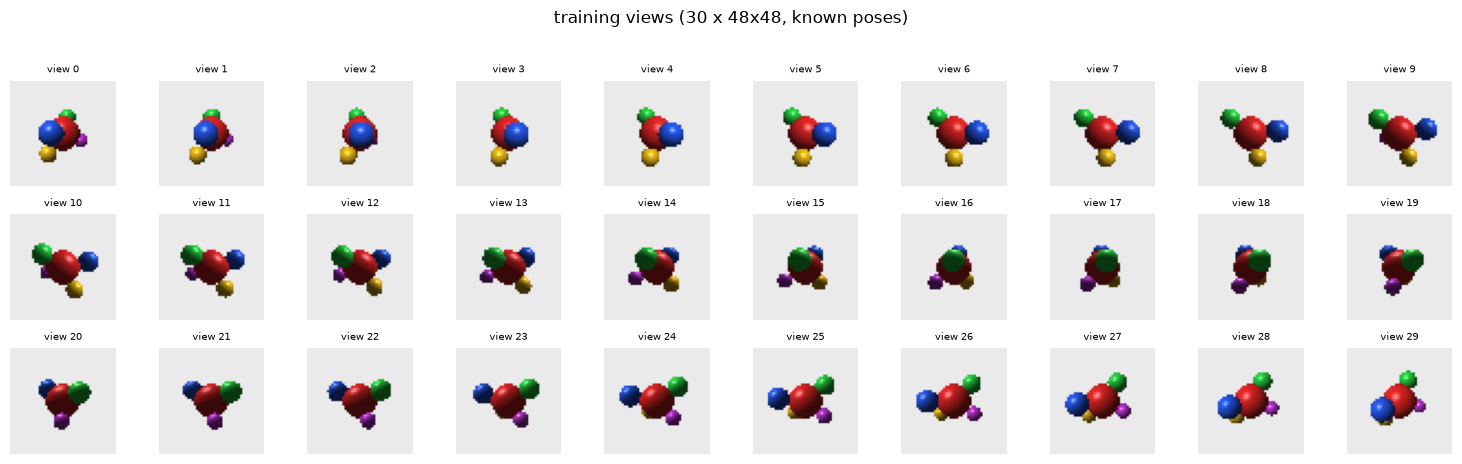

In [4]:
fig, axs = plt.subplots(3, 10, figsize=(15, 4.5))
for k, ax in enumerate(axs.flat):
    ax.imshow(train_views[k]["rgb"])
    ax.set_title(f"view {k}", fontsize=7)
    ax.axis("off")
plt.suptitle("training views (30 x 48x48, known poses)", y=1.02)
plt.tight_layout()
plt.savefig("assets/training_views.png", dpi=110, bbox_inches="tight")
plt.show()

## 4. Build the Model

### 4.1 Positional encoding:让 MLP 学会高频细节

一个反直觉的事实:直接把 `(x, y, z)` 喂给 MLP,它**学不出锐利边界** —— ReLU MLP 有 spectral bias,天然偏好低频函数(Rahaman et al., 2019),渲染结果会糊成一团。

NeRF 的解法是把每个坐标映射到一组不同频率的 sin/cos:

$$\gamma(p) = \big[\sin(2^0\pi p), \cos(2^0\pi p), \dots, \sin(2^{L-1}\pi p), \cos(2^{L-1}\pi p)\big]$$

频率由参数 `L` 控制:`L` 越大,能表达的细节越锐利,但也越容易过拟合视角数。我们取 `L_pos=6`(位置)、`L_dir=4`(方向)。

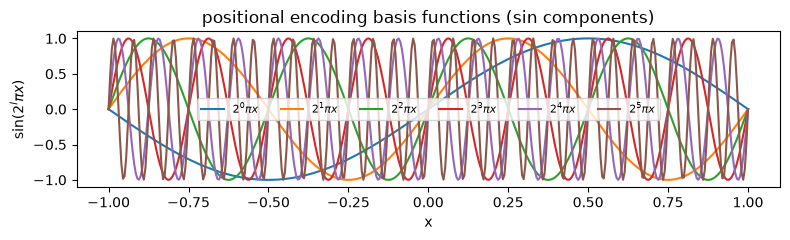

In [5]:
def posenc(x, L):
    """gamma(x): (..., C) -> (..., C + 2*C*L), 频率 2^0 .. 2^(L-1)."""
    out = [x]
    for l in range(L):
        f = (2.0 ** l) * np.pi
        out += [torch.sin(f * x), torch.cos(f * x)]
    return torch.cat(out, dim=-1)

L_POS, L_DIR = 6, 4
IN_POS = 3 + 2 * 3 * L_POS   # 39
IN_DIR = 3 + 2 * 3 * L_DIR   # 27

# 直观感受一下: 一维输入 x 经过 posenc 后变成一组不同频率的基函数
xs = torch.linspace(-1, 1, 400)[:, None]
fig, ax = plt.subplots(figsize=(8, 2.5))
for l in range(L_POS):
    ax.plot(xs[:, 0], torch.sin((2.0 ** l) * np.pi * xs)[:, 0], label=f"$2^{l}\pi x$")
ax.set(title="positional encoding basis functions (sin components)",
       xlabel="x", ylabel="$\sin(2^l \pi x)$")
ax.legend(ncol=6, fontsize=8)
plt.tight_layout()
plt.savefig("assets/posenc_basis.png", dpi=130)
plt.show()

### 4.2 TinyNeRF:密度只看位置,颜色还看方向

网络分成两段(这是原 NeRF 的关键设计,不是随意选择):

1. **trunk**:输入 positional-encoded 位置 `γ(x)`,输出**密度 σ** 和一个 feature vector;
2. **color head**:输入 feature + positional-encoded 方向 `γ(d)`,输出 **rgb**。

为什么这样拆?
- **σ(几何)必须与观察方向无关** —— 一个点是不是"实心",不取决于你站在哪看。让 σ 只看 `x`,就把这条物理约束硬编码进了网络;
- **颜色可以(且应该)依赖方向** —— 高光、镜面反射都是 view-dependent 的(回忆 3.1 里故意加的 specular)。

规模刻意小:trunk 两层 96 维,color head 一层 48 维,总共约 1.5 万个参数(原版 NeRF 是 8×256)。

In [6]:
class TinyNeRF(nn.Module):
    """F_theta: (position, direction) -> (sigma, rgb)"""
    def __init__(self, hidden=96):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(IN_POS, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.sigma_head = nn.Linear(hidden, 1)          # 密度: 只看位置
        self.color_head = nn.Sequential(                # 颜色: 位置特征 + 观察方向
            nn.Linear(hidden + IN_DIR, hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, 3),
        )

    def forward(self, x, d):
        """x, d: (N, 3) -> sigma (N,1), rgb (N,3)"""
        h = self.trunk(posenc(x, L_POS))
        sigma = torch.relu(self.sigma_head(h))                       # sigma >= 0
        rgb = torch.sigmoid(self.color_head(torch.cat([h, posenc(d, L_DIR)], dim=-1)))
        return sigma, rgb

model = TinyNeRF()
n_params = sum(p.numel() for p in model.parameters())
print(f"TinyNeRF parameters: {n_params:,}  (原版 NeRF: ~1.2M)")

TinyNeRF parameters: 19,348  (原版 NeRF: ~1.2M)


### 4.3 Volume rendering:把一条 ray 上的点积成像素颜色

对一个像素,相机发出 ray `r(t) = o + t·d`,在 `[near, far]` 之间均匀采 `N` 个点,查询 MLP 得到每点的 `(σ_i, c_i)`,然后做**体渲染积分**(离散形式):

$$\hat C(r) = \sum_i T_i\, \alpha_i\, c_i, \qquad \alpha_i = 1 - e^{-\sigma_i \delta}, \qquad T_i = \prod_{j<i}(1 - \alpha_j)$$

直觉:
- `α_i` 是 ray 在第 `i` 段**被吸收**的概率(σ 越大、步长 δ 越大,越可能撞上东西);
- `T_i`(**transmittance**)是 ray **活到第 i 段**的概率 —— 一路没被挡住;
- 最终颜色 = 各段颜色按"在这里停下"的概率加权;没被任何段吸收的部分 `(1 - Σw)` 补上背景色。

同一组权重 `w_i = T_i α_i` 还能给出**深度图**:`depth = Σ w_i t_i`(期望终止深度),Section 6.2 会用到。

整条链路只有加法、乘法、exp、MLP —— **完全可微**,这就是 NeRF 能被 SGD 训练的原因。

In [7]:
NEAR, FAR, N_SAMPLES = 2.0, 4.0, 32   # 相机半径 3, 场景在原点附近 -> ray 的 [2,4] 段覆盖所有球
T_VALS = torch.linspace(NEAR, FAR, N_SAMPLES)
DELTA = (FAR - NEAR) / N_SAMPLES

def render_rays(model, ro, rd):
    """NeRF volume rendering. ro, rd: (B, 3) -> rgb (B,3), depth (B,), acc (B,)"""
    B = ro.shape[0]
    pts = ro[:, None, :] + rd[:, None, :] * T_VALS[None, :, None]      # (B, N, 3) 沿 ray 采样
    dirs = rd[:, None, :].expand_as(pts)
    sigma, rgb = model(pts.reshape(-1, 3), dirs.reshape(-1, 3))        # 查询 MLP
    sigma = sigma.reshape(B, N_SAMPLES)
    rgb = rgb.reshape(B, N_SAMPLES, 3)

    alpha = 1.0 - torch.exp(-sigma * DELTA)                            # 每段吸收概率
    trans = torch.cumprod(                                             # T_i: 活到第 i 段的概率
        torch.cat([torch.ones_like(alpha[:, :1]), 1.0 - alpha + 1e-10], dim=1), dim=1)[:, :-1]
    w = alpha * trans                                                  # (B, N) 每段权重
    acc = w.sum(dim=1)                                                 # ray 被吸收的总概率
    rgb_out = (w[..., None] * rgb).sum(dim=1) + (1.0 - acc[:, None]) * BG_COLOR
    depth = (w * T_VALS[None, :]).sum(dim=1) / (acc + 1e-8)            # 期望终止深度
    return rgb_out, depth, acc

print("render_rays ready — 一条 ray:", N_SAMPLES, "个采样点, 积分区间 [%.1f, %.1f]" % (NEAR, FAR))

render_rays ready — 一条 ray: 32 个采样点, 积分区间 [2.0, 4.0]


## 5. Train

训练循环朴素得不像 3D 重建算法:

1. 把 30 张训练图的所有 pixel ray 摊平成一个池子(30 × 48 × 48 ≈ 6.9 万条);
2. 每步随机抽 1024 条 ray,用 NeRF 渲染出颜色,与解析渲染器的 ground truth 算 **MSE**;
3. Adam 反向传播。

没有 mesh、没有点云、没有显式几何 —— **梯度是唯一的信息通道**:每个像素都在投票"我这条 ray 上应该有什么样的密度和颜色",MLP 在数万次投票中逐渐凝结出场景的 3D 结构。

我们同时记录训练 PSNR(Peak Signal-to-Noise Ratio,`−10·log₁₀(MSE)`,越高越好;>20 dB 大致可辨,>25 dB 相当清晰)。CPU 上 3000 步约 1–2 分钟。

In [8]:
def stack_views(views):
    """把若干视角摊平成 ray 池: ro, rd, rgb 各 (n_views*H*W, 3) 的 torch tensor."""
    ro = torch.from_numpy(np.concatenate([v["ro"].reshape(-1, 3) for v in views]))
    rd = torch.from_numpy(np.concatenate([v["rd"].reshape(-1, 3) for v in views]))
    rgb = torch.from_numpy(np.concatenate([v["rgb"].reshape(-1, 3) for v in views]))
    return ro, rd, rgb

def train_nerf(views, n_iters=3000, batch=1024, lr=5e-3, log_every=100, verbose=True):
    """在给定视角集合上训练一个 TinyNeRF, 返回 (model, history)."""
    ro, rd, rgb = stack_views(views)
    n_rays = ro.shape[0]
    model = TinyNeRF()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.1 ** (1.0 / n_iters))
    hist = []
    t0 = time.time()
    for it in range(1, n_iters + 1):
        idx = torch.randint(0, n_rays, (batch,))
        pred, _, _ = render_rays(model, ro[idx], rd[idx])
        loss = ((pred - rgb[idx]) ** 2).mean()
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()
        if it % log_every == 0:
            psnr = -10.0 * np.log10(loss.item())
            hist.append((it, loss.item(), psnr))
            if verbose and it % (log_every * 5) == 0:
                print(f"iter {it:5d} | loss {loss.item():.5f} | PSNR {psnr:5.1f} dB | {time.time()-t0:.0f}s")
    return model, hist

model, hist = train_nerf(train_views, n_iters=3000)
print(f"done. final train PSNR: {hist[-1][2]:.1f} dB")

iter   500 | loss 0.00279 | PSNR  25.5 dB | 19s


iter  1000 | loss 0.00105 | PSNR  29.8 dB | 40s


iter  1500 | loss 0.00092 | PSNR  30.4 dB | 59s


iter  2000 | loss 0.00098 | PSNR  30.1 dB | 80s


iter  2500 | loss 0.00055 | PSNR  32.6 dB | 101s


iter  3000 | loss 0.00054 | PSNR  32.7 dB | 121s
done. final train PSNR: 32.7 dB


## 6. Visualize

### 6.1 训练曲线:loss 与 PSNR

loss 应该稳定下降两个数量级以上,PSNR 爬升到 25 dB 附近。注意曲线不是单调的 —— 每步是随机 ray batch,loss 天然有噪声。

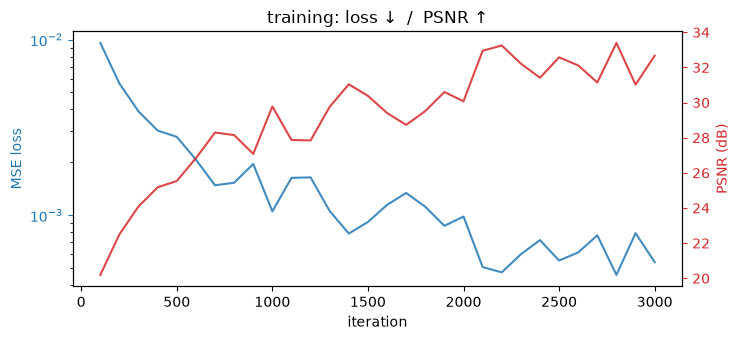

In [9]:
iters = [h[0] for h in hist]; losses = [h[1] for h in hist]; psnrs = [h[2] for h in hist]
fig, ax1 = plt.subplots(figsize=(7.5, 3.5))
ax1.plot(iters, losses, color="tab:blue", alpha=0.85)
ax1.set(xlabel="iteration", ylabel="MSE loss", yscale="log")
ax1.yaxis.label.set_color("tab:blue"); ax1.tick_params(axis="y", colors="tab:blue")
ax2 = ax1.twinx()
ax2.plot(iters, psnrs, color="tab:red", alpha=0.85)
ax2.set_ylabel("PSNR (dB)"); ax2.yaxis.label.set_color("tab:red"); ax2.tick_params(axis="y", colors="tab:red")
plt.title("training: loss ↓  /  PSNR ↑")
plt.tight_layout()
plt.savefig("assets/loss_psnr.png", dpi=130)
plt.show()

### 6.2 渲染任意视角:train view vs novel view vs ground truth

有了训练好的 `model`,渲染一整张图就是:对该视角所有像素生成 ray → `render_rays` → reshape。下面定义 `render_view`,然后对比三类图像:

- **训练视角重建**(模型"见过"的角度):应当接近完美;
- **novel view**(从未见过的方位角 + 仰角):这才是 novel view synthesis 的试金石;
- 两者的 **ground truth** 解析渲染作对照。

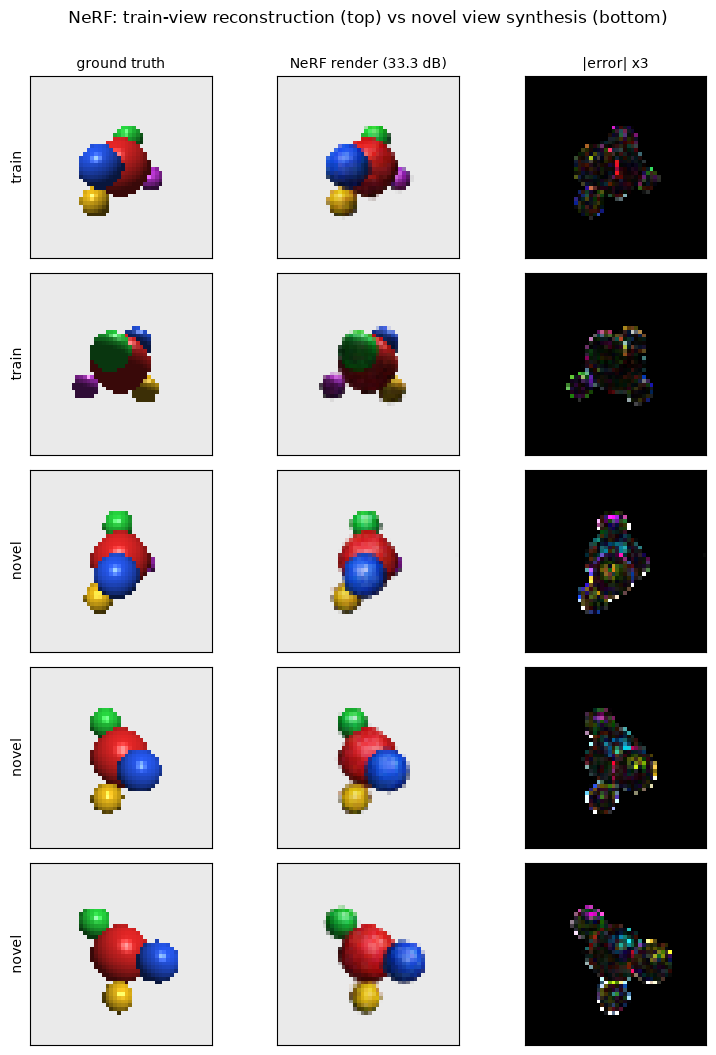

In [10]:
def render_view(model, eye, c2w, chunk=4096):
    """用 NeRF 渲染一整张图 + 深度图. 返回 rgb (H,W,3), depth (H,W), acc (H,W)."""
    model.eval()
    ro, rd = get_rays(eye, c2w)
    ro = torch.from_numpy(ro.reshape(-1, 3)); rd = torch.from_numpy(rd.reshape(-1, 3))
    rgbs, depths, accs = [], [], []
    with torch.no_grad():
        for s in range(0, ro.shape[0], chunk):
            rgb, dep, acc = render_rays(model, ro[s:s+chunk], rd[s:s+chunk])
            rgbs.append(rgb); depths.append(dep); accs.append(acc)
    return (torch.cat(rgbs).numpy().reshape(H, W, 3),
            torch.cat(depths).numpy().reshape(H, W),
            torch.cat(accs).numpy().reshape(H, W))

def psnr(a, b):
    return -10.0 * np.log10(np.mean((np.clip(a, 0, 1) - b) ** 2))

# 2 个训练视角 + 3 个 novel 视角
show = [("train", train_views[0]), ("train", train_views[15]),
        ("novel", test_views[1]), ("novel", test_views[3]), ("novel", test_views[5])]
fig, axs = plt.subplots(len(show), 3, figsize=(8, 2.1 * len(show)))
for row, (kind, v) in enumerate(show):
    pred, dep, acc = render_view(model, v["eye"], v["c2w"])
    p = psnr(pred, v["rgb"])
    axs[row, 0].imshow(v["rgb"]); axs[row, 0].set_ylabel(kind, fontsize=10)
    axs[row, 1].imshow(np.clip(pred, 0, 1))
    axs[row, 2].imshow(np.clip(np.abs(np.clip(pred, 0, 1) - v["rgb"]) * 3, 0, 1))  # 误差放大 3 倍
    for c, t in enumerate(["ground truth", f"NeRF render ({p:.1f} dB)", "|error| x3"]):
        if row == 0: axs[row, c].set_title(t, fontsize=10)
    for c in range(3): axs[row, c].set_xticks([]); axs[row, c].set_yticks([])
plt.suptitle("NeRF: train-view reconstruction (top) vs novel view synthesis (bottom)", y=1.0)
plt.tight_layout()
plt.savefig("assets/novel_views.png", dpi=120, bbox_inches="tight")
plt.show()

### 6.3 深度图:σ 里藏着几何

我们**从未给模型任何深度监督** —— 只有 RGB。但 volume rendering 的权重 `w_i` 自动给出了每条 ray 的期望终止深度 `Σ w_i t_i`:多视角一致性迫使 σ 在真实表面处形成尖峰,几何是"免费"涌现的。

下面把深度图与 RGB 渲染并排展示(背景处 `acc≈0`,深度无意义,显示为 far 端)。

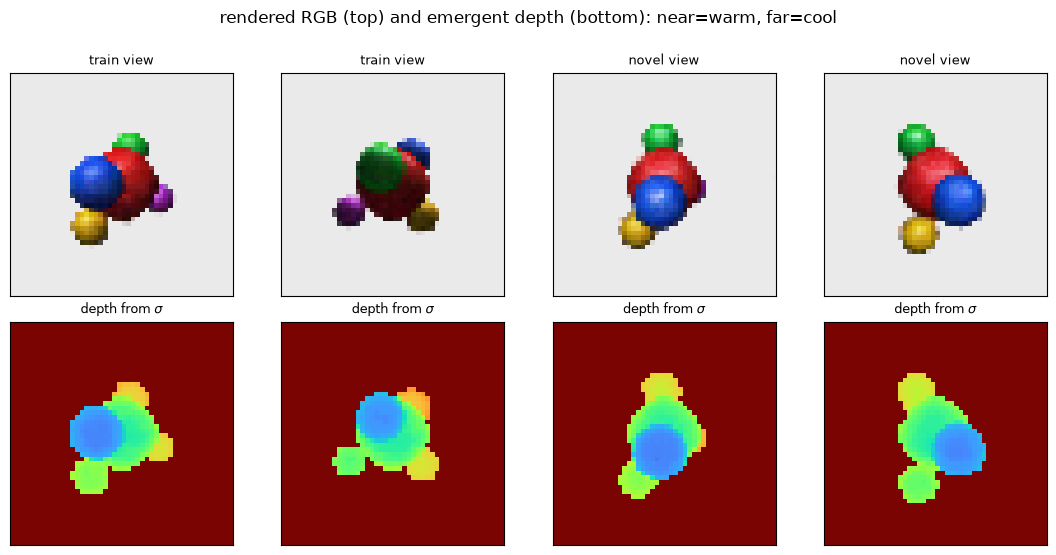

In [11]:
fig, axs = plt.subplots(2, 4, figsize=(11, 5.5))
depth_show = [("train", train_views[0]), ("train", train_views[15]),
              ("novel", test_views[1]), ("novel", test_views[3])]
for col, (kind, v) in enumerate(depth_show):
    pred, dep, acc = render_view(model, v["eye"], v["c2w"])
    dep_disp = np.where(acc > 0.3, dep, FAR)
    axs[0, col].imshow(np.clip(pred, 0, 1))
    axs[1, col].imshow(dep_disp, cmap="turbo", vmin=NEAR, vmax=FAR)
    axs[0, col].set_title(kind + " view", fontsize=9)
    axs[1, col].set_title("depth from $\sigma$", fontsize=9)
    for r in range(2): axs[r, col].set_xticks([]); axs[r, col].set_yticks([])
plt.suptitle("rendered RGB (top) and emergent depth (bottom): near=warm, far=cool", y=1.0)
plt.tight_layout()
plt.savefig("assets/depth_maps.png", dpi=120, bbox_inches="tight")
plt.show()

### 6.4 360° 环绕:NeRF 的"毕业演出"

让相机在固定仰角上绕场景转一整圈(60 帧),逐帧用 NeRF 渲染,拼成 GIF。相机轨迹可以**任意** —— 这正是"场景被装进了一个连续函数"的含义:渲染视角不再受限于拍摄视角。

saved assets/orbit.gif (60 frames)


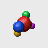

In [12]:
N_FRAMES = 60
frames = []
for k in range(N_FRAMES):
    th = 2 * np.pi * k / N_FRAMES
    eye, c2w = make_pose(th, elev=np.deg2rad(24))
    rgb, _, _ = render_view(model, eye, c2w)
    frames.append((np.clip(rgb, 0, 1) * 255).astype(np.uint8))
imageio.mimsave("assets/orbit.gif", frames, fps=15, loop=0)
print(f"saved assets/orbit.gif ({N_FRAMES} frames)")

from IPython.display import Image as IPyImage
IPyImage(filename="assets/orbit.gif")

## 7. Evaluate:数字与画面同样重要

对**全部 30 个训练视角**与 **6 个 held-out novel 视角**分别计算 PSNR:

- **train PSNR > novel PSNR** 是正常的(模型见过训练视角),但如果两者差距很小,说明模型学到的是**真实的 3D 结构**而不是死记硬背 30 张图;
- 如果 novel PSNR 崩盘,说明视角覆盖不够或过拟合 —— Section 8 会人为制造这种失败。

train views (30):  PSNR 32.4 ± 0.8 dB  (min 30.6)
novel views (6):   PSNR 27.4 ± 0.6 dB  (min 26.7)
generalization gap: 5.0 dB


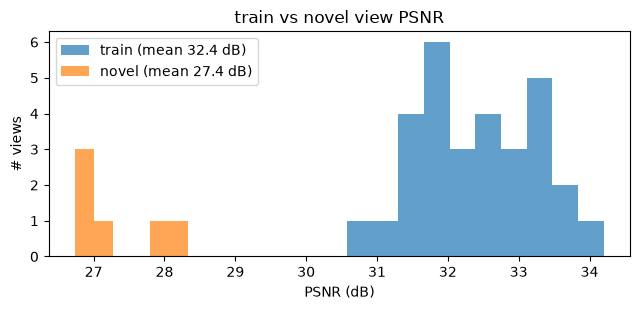

In [13]:
def eval_psnr(model, views):
    return np.array([psnr(render_view(model, v["eye"], v["c2w"])[0], v["rgb"]) for v in views])

train_psnrs = eval_psnr(model, train_views)
novel_psnrs = eval_psnr(model, test_views)
print(f"train views (30):  PSNR {train_psnrs.mean():.1f} ± {train_psnrs.std():.1f} dB  (min {train_psnrs.min():.1f})")
print(f"novel views (6):   PSNR {novel_psnrs.mean():.1f} ± {novel_psnrs.std():.1f} dB  (min {novel_psnrs.min():.1f})")
print(f"generalization gap: {train_psnrs.mean() - novel_psnrs.mean():.1f} dB")

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.hist(train_psnrs, bins=10, alpha=0.7, label=f"train (mean {train_psnrs.mean():.1f} dB)")
ax.hist(novel_psnrs, bins=6, alpha=0.7, label=f"novel (mean {novel_psnrs.mean():.1f} dB)")
ax.set(xlabel="PSNR (dB)", ylabel="# views", title="train vs novel view PSNR")
ax.legend()
plt.tight_layout()
plt.savefig("assets/psnr_hist.png", dpi=130)
plt.show()

## 8. Experiment:砍掉训练视角,会发生什么?

NeRF 的样本效率完全来自**多视角约束**:30 个视角下,一个错误的 3D 结构几乎不可能同时骗过所有照片。但视角太少时,约束不足,模型会找到"作弊解" —— 比如在半空中放一团**雾状密度(floater)**,恰好挡住训练 ray,从训练视角看毫无破绽,换个角度立刻露馅。

下面只用 **8 个训练视角**(同样的网络、同样的步数)重训一个模型,对比 novel view PSNR 与画面质量。预期:训练视角 PSNR 依然很高(背下来了),novel view 显著退化、出现雾状伪影 —— **train/novel gap 拉大就是过拟合的信号**。

retraining on 8 views (was 30) ...



[ 8 views] train PSNR 37.7 dB | novel PSNR 24.3 dB | gap 13.3 dB
[30 views] train PSNR 32.4 dB | novel PSNR 27.4 dB | gap 5.0 dB


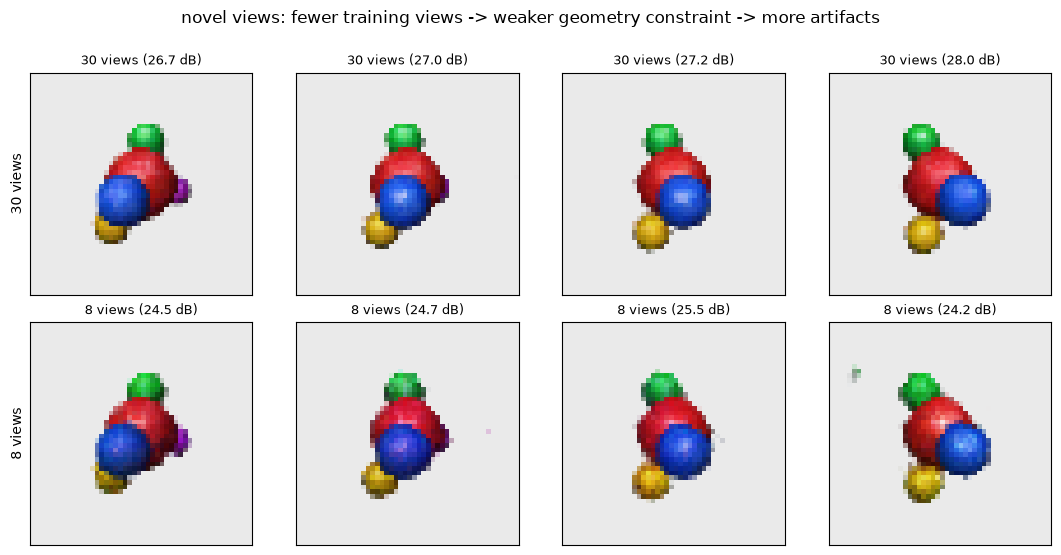

In [14]:
few_views = train_views[::4]   # 8 个视角
print(f"retraining on {len(few_views)} views (was {len(train_views)}) ...")
model_few, hist_few = train_nerf(few_views, n_iters=3000, verbose=False)

few_train_psnrs = eval_psnr(model_few, few_views)
few_novel_psnrs = eval_psnr(model_few, test_views)
print(f"\n[ 8 views] train PSNR {few_train_psnrs.mean():.1f} dB | novel PSNR {few_novel_psnrs.mean():.1f} dB | gap {few_train_psnrs.mean()-few_novel_psnrs.mean():.1f} dB")
print(f"[30 views] train PSNR {train_psnrs.mean():.1f} dB | novel PSNR {novel_psnrs.mean():.1f} dB | gap {train_psnrs.mean()-novel_psnrs.mean():.1f} dB")

fig, axs = plt.subplots(2, 4, figsize=(11, 5.5))
for col, v in enumerate(test_views[:4]):
    rgb_full, _, _ = render_view(model, v["eye"], v["c2w"])
    rgb_few, _, _ = render_view(model_few, v["eye"], v["c2w"])
    axs[0, col].imshow(np.clip(rgb_full, 0, 1))
    axs[0, col].set_title(f"30 views ({psnr(rgb_full, v['rgb']):.1f} dB)", fontsize=9)
    axs[1, col].imshow(np.clip(rgb_few, 0, 1))
    axs[1, col].set_title(f"8 views ({psnr(rgb_few, v['rgb']):.1f} dB)", fontsize=9)
    for r in range(2): axs[r, col].set_xticks([]); axs[r, col].set_yticks([])
axs[0, 0].set_ylabel("30 views", fontsize=10); axs[1, 0].set_ylabel("8 views", fontsize=10)
plt.suptitle("novel views: fewer training views -> weaker geometry constraint -> more artifacts", y=1.0)
plt.tight_layout()
plt.savefig("assets/few_views.png", dpi=120, bbox_inches="tight")
plt.show()

## 9. Questions(思考题)

1. **为什么 σ 不能让 direction 参与?** 如果 σ = σ(x, d),模型可以获得一种作弊能力:让某个 3D 点"只从你的训练相机方向看是不透明的"。这在训练集上不损失任何 loss,但 novel view 会怎样?
2. **为什么训练视角要覆盖一个仰角"带"而不只是一个"环"?** 如果 30 个训练视角全部固定在同一仰角上,novel view 换了仰角后会发生什么?这反映了 NeRF 泛化的什么本质(插值 vs 外推)?
3. **体积渲染里的背景色 `BG_COLOR` 出现在公式哪里?** 如果场景背景是纯黑而我们用 0.92 的浅灰做背景合成,loss 会迫使 σ 往哪个方向走?
4. **NeRF 的分辨率瓶颈在哪?** 把图像从 48×48 提到 256×256,ray 数量涨 28 倍,MLP 查询量同步暴涨。原版 NeRF 为此用了什么技巧(coarse-to-fine 采样)?Mip-NeRF 又解决了什么更根本的问题(像素是点还是面积)?
5. **本 Lab 的 NeRF 能用于 Lab 4 的 planning 吗?** 缺什么?(提示:回想 Motivation 里的对比表。)

### ✏️ Exercise 1 — positional encoding 的频率数

把 `L_POS` 从 6 降到 2,重训模型(`train_nerf(train_views, n_iters=3000)`),对比 novel view 的锐度。再把 `L_POS` 提到 10,观察是否出现过拟合/噪声。频率数在控制什么 trade-off?

In [15]:
# YOUR CODE HERE
# hint: L_POS = 2
#       IN_POS = 3 + 2 * 3 * L_POS      # 记得同步改输入维度!
#       model_l2, hist_l2 = train_nerf(train_views, n_iters=3000, verbose=False)
#       rgb_l2, _, _ = render_view(model_l2, test_views[1]["eye"], test_views[1]["c2w"])
#       plt.imshow(np.clip(rgb_l2, 0, 1)); plt.show()

### ✏️ Exercise 2 — ray 上的采样点数

`N_SAMPLES` 从 32 降到 8(步长 δ 变粗),重训并对比:渲染还锐利吗?深度图呢?再想想:除了均匀采样,能不能先用一个粗网络找到密度大的区段、再在那里加密采样(hierarchical sampling)?这就是原 NeRF 的 coarse→fine 两级结构。

In [16]:
# YOUR CODE HERE
# hint: N_SAMPLES = 8
#       T_VALS = torch.linspace(NEAR, FAR, N_SAMPLES)
#       DELTA = (FAR - NEAR) / N_SAMPLES
#       model_s8, _ = train_nerf(train_views, n_iters=3000, verbose=False)
#       rgb_s8, dep_s8, acc_s8 = render_view(model_s8, test_views[1]["eye"], test_views[1]["c2w"])
#       ...与 30-view 模型并排画图对比...

## Advanced Extension(可选):从 NeRF 到 3D Gaussian Splatting

NeRF 用**隐式**表示(场景装在 MLP 权重里),渲染一个像素要查几十次网络 —— 慢。**3DGS** 换成**显式**表示:场景 = 一堆 3D 高斯椭球,每个带位置 μ、协方差 Σ(旋转 + 缩放)、颜色与不透明度 α。渲染时把每个 3D 高斯**投影(splat)到成像平面**成为 2D 高斯,按深度排序后做 **α-blending**:

$$C = \sum_i c_i\, \alpha_i\, G_i^{2D}(p) \prod_{j<i}\big(1 - \alpha_j G_j^{2D}(p)\big)$$

形式上和 NeRF 的体渲染一模一样(transmittance × α × color),只是把"沿 ray 采样"换成了"把高斯拍扁到屏幕上"。全部参数直接可微,渲染靠光栅化而非逐点查询 —— 这就是它能实时(100+ FPS)的原因。

下面用一个**简版 2D splatting** 演示核心机制:8 个手工放置的 2D 高斯,按深度顺序 α-blend 成一幅图。左图是每个高斯"长什么样",右图是合成结果。

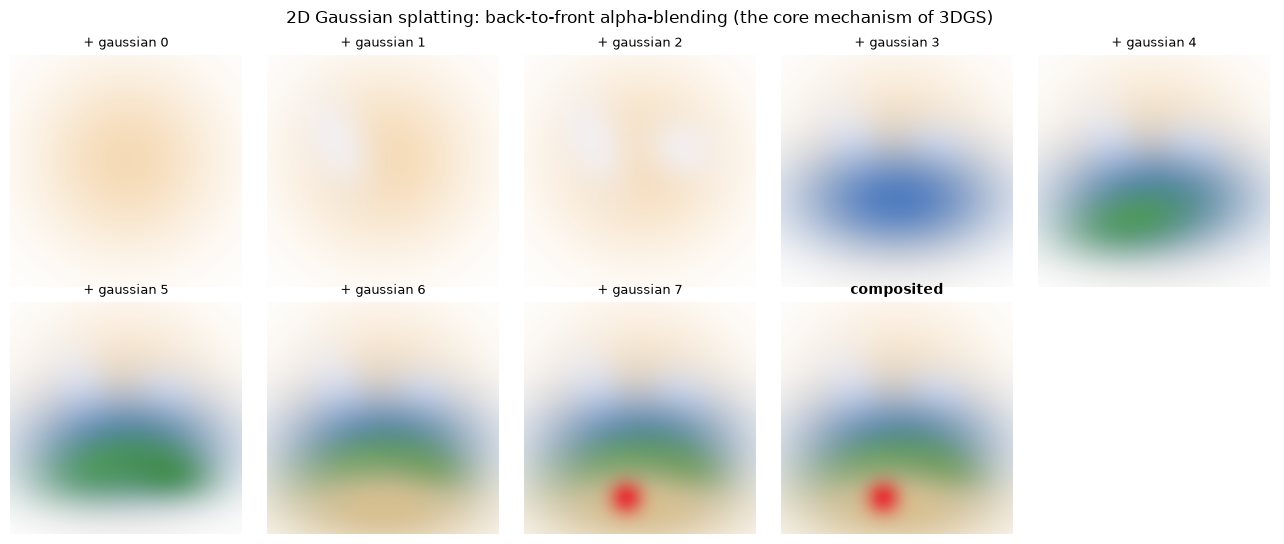

In [17]:
# ---- 简版 2D Gaussian Splatting: 手工摆 8 个高斯, alpha-blend 成一幅画 ----
gaussians2d = [  # (mu_x, mu_y, sx, sy, rot, color, alpha, z)  z 大的先画(远)
    (0.50, 0.55, 0.28, 0.28, 0.0,  [0.96, 0.85, 0.70], 0.95, 8),  # 天空暖光
    (0.30, 0.62, 0.10, 0.16, 0.4,  [0.95, 0.95, 0.98], 0.80, 7),  # 云
    (0.68, 0.60, 0.12, 0.10, -0.3, [0.95, 0.95, 0.98], 0.75, 6),
    (0.50, 0.38, 0.30, 0.16, 0.0,  [0.25, 0.45, 0.75], 0.90, 5),  # 远山
    (0.42, 0.30, 0.20, 0.10, 0.2,  [0.30, 0.60, 0.35], 0.90, 4),  # 树丛
    (0.66, 0.28, 0.14, 0.08, -0.2, [0.25, 0.55, 0.30], 0.90, 3),
    (0.50, 0.12, 0.32, 0.14, 0.0,  [0.85, 0.75, 0.55], 0.95, 2),  # 地面
    (0.44, 0.16, 0.05, 0.05, 0.0,  [0.90, 0.20, 0.20], 0.95, 1),  # 红花(最近)
]

def eval_gaussian2d(grid, mu, sx, sy, rot):
    """在各向异性高斯上评估 grid 点 -> (P,) 未归一化密度."""
    c, s = np.cos(rot), np.sin(rot)
    R = np.array([[c, -s], [s, c]])
    prec = R @ np.diag([1 / sx**2, 1 / sy**2]) @ R.T          # 精度矩阵 Sigma^-1
    d = grid - mu
    maha = np.einsum("pi,ij,pj->p", d, prec, d)
    return np.exp(-0.5 * maha)

P = 240
yy, xx = np.mgrid[0:P, 0:P]
grid = np.stack([xx.ravel() / P, 1 - yy.ravel() / P], axis=1)  # (P*P, 2), y 向上

canvas = np.ones((P * P, 3), dtype=np.float32)                 # 白底
layers = []
for mu_x, mu_y, sx, sy, rot, color, alpha, z in sorted(gaussians2d, key=lambda g: -g[7]):
    g = eval_gaussian2d(grid, np.array([mu_x, mu_y]), sx, sy, rot)
    a = (alpha * g)[:, None]
    layers.append((np.array(color) * a + canvas * (1 - a)))    # over 合成
    canvas = layers[-1]

fig, axs = plt.subplots(2, len(layers) // 2 + 1, figsize=(13, 5.5))
for k, ax in enumerate(axs.flat):
    ax.axis("off")
    if k < len(layers):
        ax.imshow(layers[k].reshape(P, P, 3).clip(0, 1))
        ax.set_title(f"+ gaussian {k}", fontsize=9)
    elif k == len(layers):
        ax.imshow(canvas.reshape(P, P, 3).clip(0, 1))
        ax.set_title("composited", fontsize=10, fontweight="bold")
plt.suptitle("2D Gaussian splatting: back-to-front alpha-blending (the core mechanism of 3DGS)")
plt.tight_layout()
plt.savefig("assets/splatting_2d.png", dpi=120, bbox_inches="tight")
plt.show()

**2D demo 只展示了合成机制**:高斯是手摆的,没有从 3D 投影,也没有学习。下一节把这三件事补上:在同一个五球场景上,用和 NeRF 完全相同的数据与损失,训练一个真正的 3D Gaussian Splatting。

## Advanced Extension B:亲手训练一个 tiny 3D Gaussian Splatting

上面的 2D demo 是手摆的。现在把它变成真正的 3DGS:**同一个场景、同样 30 张训练图、同样的 photometric MSE**,只是把 NeRF 的"MLP + 沿 ray 采样"换成"一堆可学习的 3D 高斯 + splatting"。

**每个高斯的参数**(全部直接用梯度下降学):

| 参数 | 形状 | 含义 |
|---|---|---|
| 位置 μ | 3 | 高斯中心 |
| 尺度 s(存 log) | 3 | 三个主轴的标准差 |
| 旋转 q(四元数) | 4 | 主轴朝向,$\Sigma = R\,S\,S^\top R^\top$ 保证协方差正定 |
| 颜色 c(存 logit) | 3 | 这里不随视角变化(真实 3DGS 用球谐函数表达 view-dependent 颜色) |
| 不透明度 α(存 logit) | 1 | |

**渲染 = 投影 + 排序 + α-blending**:

1. 把中心变到相机坐标,按深度 $d$ 排序(近的在前);
2. 把 3D 协方差投影成屏幕上的 2D 协方差(EWA splatting):$\Sigma' = J\,W\,\Sigma\,W^\top J^\top$,其中 $W$ 是世界→相机旋转,$J$ 是透视投影在该点的 Jacobian;
3. 每个像素按深度顺序合成:$C = \sum_i c_i\,\alpha_i' \prod_{j<i}(1-\alpha_j') + T_{\text{final}}\cdot \text{bg}$,其中 $\alpha_i' = \alpha_i \exp\!\big(-\tfrac12 \Delta^\top \Sigma_i'^{-1}\Delta\big)$。

和 NeRF 的体渲染公式逐项对应:transmittance × α × color。区别在于这里**没有网络、没有沿 ray 采样**——每个像素只需要对高斯做一次解析求值。

**初始化**:真实 3DGS 用 COLMAP(SfM)重建出的稀疏点云初始化高斯中心。我们没有跑 SfM,但手里有一个训练好的 NeRF,它的深度图(Section 6.3)就是现成的几何:把几张训练视角的深度反投影成点云,随机取 N 个点当高斯中心,用对应像素的颜色初始化颜色。

In [18]:
# ---- tiny 3DGS: 可学习的 3D 高斯 + 可微 splatting 渲染器 ----
def quat_to_rotmat(q):
    """(N,4) 四元数 (w,x,y,z) -> (N,3,3) 旋转矩阵; 先归一化, 所以 q 可以自由优化."""
    q = q / q.norm(dim=-1, keepdim=True)
    w, x, y, z = q.unbind(-1)
    return torch.stack([1 - 2*(y*y + z*z), 2*(x*y - w*z),     2*(x*z + w*y),
                        2*(x*y + w*z),     1 - 2*(x*x + z*z), 2*(y*z - w*x),
                        2*(x*z - w*y),     2*(y*z + w*x),     1 - 2*(x*x + y*y)], -1).reshape(-1, 3, 3)

class TinyGaussians(nn.Module):
    def __init__(self, means, colors, init_scale=0.05):
        super().__init__()
        n = len(means)
        self.means = nn.Parameter(torch.as_tensor(means, dtype=torch.float32).clone())
        self.log_scales = nn.Parameter(torch.full((n, 3), float(np.log(init_scale))))
        self.quats = nn.Parameter(torch.tensor([[1.0, 0.0, 0.0, 0.0]]).repeat(n, 1))
        c = torch.as_tensor(colors, dtype=torch.float32).clamp(0.02, 0.98)
        self.color_logits = nn.Parameter(torch.log(c / (1 - c)))       # sigmoid 的反函数
        self.opacity_logits = nn.Parameter(torch.full((n,), 1.0))      # sigmoid(1) ≈ 0.73

PIX_XY = torch.from_numpy(np.stack(np.meshgrid(np.arange(W), np.arange(H), indexing="xy"), -1)
                          .reshape(-1, 2).astype(np.float32))           # (H*W, 2) 像素坐标 (i, j)

def render_gaussians(gs, eye, c2w, bg=BG_COLOR):
    """把所有高斯 splat 到 (H, W) 图像上. 与 get_rays 用同一个 pinhole 约定."""
    R = torch.from_numpy(c2w.astype(np.float32))                       # cam2world, 列 = right / up / back
    p = (gs.means - torch.from_numpy(eye.astype(np.float32))) @ R      # 世界 -> 相机坐标
    d = -p[:, 2]                                                       # 深度 (相机看向 -z)
    keep = d > 0.1                                                     # 只保留相机前方的高斯
    p, d = p[keep], d[keep]
    S = torch.exp(gs.log_scales[keep])
    M = quat_to_rotmat(gs.quats[keep]) * S[:, None, :]                 # R @ diag(S)
    cov_cam = R.T @ (M @ M.transpose(1, 2)) @ R                        # 相机系下的 3D 协方差
    J = torch.zeros(len(d), 2, 3)                                      # 透视投影的 Jacobian
    J[:, 0, 0] = FOCAL / d; J[:, 0, 2] = FOCAL * p[:, 0] / d**2
    J[:, 1, 1] = -FOCAL / d; J[:, 1, 2] = -FOCAL * p[:, 1] / d**2
    cov2d = J @ cov_cam @ J.transpose(1, 2) + 0.3 * torch.eye(2)       # +0.3: 抗锯齿低通, 防止退化
    mu2d = torch.stack([W / 2 - 0.5 + FOCAL * p[:, 0] / d,
                        H / 2 - 0.5 - FOCAL * p[:, 1] / d], -1)        # 中心投影到像素坐标
    order = torch.argsort(d)                                           # 近 -> 远
    mu2d, cov2d = mu2d[order], cov2d[order]
    color = torch.sigmoid(gs.color_logits[keep][order])
    opacity = torch.sigmoid(gs.opacity_logits[keep][order])
    a, b, c = cov2d[:, 0, 0], cov2d[:, 0, 1], cov2d[:, 1, 1]           # 2x2 协方差的逆, 手写
    det = a * c - b * b
    dx = PIX_XY[:, :1] - mu2d[None, :, 0]                              # (H*W, N)
    dy = PIX_XY[:, 1:] - mu2d[None, :, 1]
    maha = (c * dx * dx - 2 * b * dx * dy + a * dy * dy) / det         # 马氏距离平方
    alpha = (opacity[None] * torch.exp(-0.5 * maha)).clamp(max=0.99)
    T = torch.cumprod(torch.cat([torch.ones(len(PIX_XY), 1), 1 - alpha[:, :-1]], 1), 1)  # transmittance
    w = alpha * T                                                      # 与 NeRF 的 w_i = T_i * alpha_i 同形
    rgb = w @ color + (1 - w.sum(1, keepdim=True)) * bg                # 没被挡住的部分 = 背景
    return rgb.reshape(H, W, 3)
print("render_gaussians ready")

render_gaussians ready


point cloud from NeRF depth: 3109 points -> 300 gaussians (4,200 parameters)


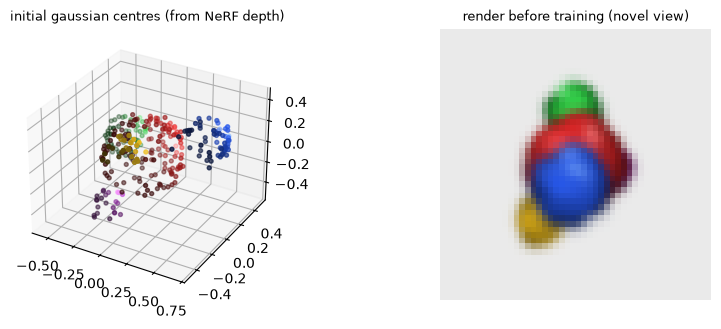

In [19]:
# ---- 初始化: 用 NeRF 的深度图代替 SfM 点云 ----
N_GAUSS = 300
pts, cols = [], []
for v in train_views[::3]:                                   # 10 个训练视角就够了
    _, dep, acc = render_view(model, v["eye"], v["c2w"])
    m = acc > 0.9                                            # 只要 NeRF 确信"撞到了东西"的像素
    pts.append(v["ro"][m] + dep[m, None] * v["rd"][m])       # 反投影: o + depth * d
    cols.append(v["rgb"][m])
pts, cols = np.concatenate(pts), np.concatenate(cols)
pick = rng.choice(len(pts), N_GAUSS, replace=False)
gs = TinyGaussians(pts[pick], cols[pick])
print(f"point cloud from NeRF depth: {len(pts)} points -> {N_GAUSS} gaussians "
      f"({sum(p.numel() for p in gs.parameters()):,} parameters)")

fig = plt.figure(figsize=(9, 3.4))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.scatter(*pts[pick].T, c=cols[pick], s=8)
ax.set_title("initial gaussian centres (from NeRF depth)", fontsize=9)
with torch.no_grad():
    init_img = render_gaussians(gs, test_views[1]["eye"], test_views[1]["c2w"]).numpy()
ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(np.clip(init_img, 0, 1)); ax2.axis("off")
ax2.set_title("render before training (novel view)", fontsize=9)
plt.tight_layout(); plt.show()

In [20]:
# ---- 训练: 每步随机一个训练视角, 整张图的 photometric MSE ----
GS_ITERS = 800
opt_gs = torch.optim.Adam([
    {"params": [gs.means],          "lr": 5e-3},
    {"params": [gs.log_scales],     "lr": 1e-2},
    {"params": [gs.quats],          "lr": 1e-2},
    {"params": [gs.color_logits],   "lr": 5e-2},
    {"params": [gs.opacity_logits], "lr": 5e-2},
])
gs_targets = [torch.from_numpy(v["rgb"]) for v in train_views]
gs_hist, t_gs = [], time.time()
for it in range(1, GS_ITERS + 1):
    k = int(rng.integers(len(train_views)))
    v = train_views[k]
    loss = ((render_gaussians(gs, v["eye"], v["c2w"]) - gs_targets[k]) ** 2).mean()
    opt_gs.zero_grad(); loss.backward(); opt_gs.step()
    gs_hist.append(loss.item())
    if it % 100 == 0:
        print(f"iter {it:4d} | loss {np.mean(gs_hist[-100:]):.5f} | {time.time() - t_gs:.0f}s")
print(f"3DGS training done in {time.time() - t_gs:.0f}s")

iter  100 | loss 0.00471 | 2s


iter  200 | loss 0.00341 | 5s


iter  300 | loss 0.00305 | 7s


iter  400 | loss 0.00294 | 9s


iter  500 | loss 0.00282 | 11s


iter  600 | loss 0.00289 | 13s


iter  700 | loss 0.00272 | 15s


iter  800 | loss 0.00277 | 18s
3DGS training done in 18s


         params  train PSNR  novel PSNR  ms / frame (CPU)
NeRF     19,348       32.4        27.4              42.0
3DGS      4,200       25.4        24.6               7.4


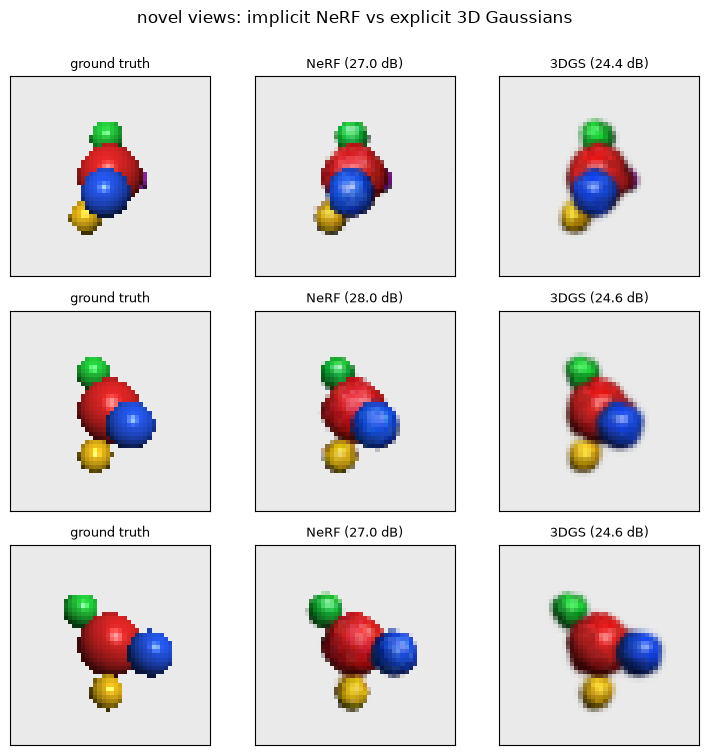

In [21]:
# ---- 评估: 画质 (PSNR) 与渲染速度, NeRF vs 3DGS ----
def render_gs_np(eye, c2w):
    with torch.no_grad():
        return render_gaussians(gs, eye, c2w).numpy()

gs_train_psnrs = np.array([psnr(render_gs_np(v["eye"], v["c2w"]), v["rgb"]) for v in train_views])
gs_novel_psnrs = np.array([psnr(render_gs_np(v["eye"], v["c2w"]), v["rgb"]) for v in test_views])

def time_render(fn, n=10):
    fn(); t = time.perf_counter()
    for _ in range(n): fn()
    return (time.perf_counter() - t) / n * 1000

v = test_views[0]
ms_nerf = time_render(lambda: render_view(model, v["eye"], v["c2w"]))
ms_gs = time_render(lambda: render_gs_np(v["eye"], v["c2w"]))
n_nerf = sum(p.numel() for p in model.parameters()); n_gs = sum(p.numel() for p in gs.parameters())
print(f"{'':6s} {'params':>8s} {'train PSNR':>11s} {'novel PSNR':>11s} {'ms / frame (CPU)':>17s}")
print(f"{'NeRF':6s} {n_nerf:8,d} {train_psnrs.mean():10.1f}  {novel_psnrs.mean():10.1f}  {ms_nerf:16.1f}")
print(f"{'3DGS':6s} {n_gs:8,d} {gs_train_psnrs.mean():10.1f}  {gs_novel_psnrs.mean():10.1f}  {ms_gs:16.1f}")

fig, axs = plt.subplots(3, 3, figsize=(7.5, 7.5))
for row, vv in enumerate([test_views[1], test_views[3], test_views[5]]):
    nerf_img = render_view(model, vv["eye"], vv["c2w"])[0]
    gs_img = render_gs_np(vv["eye"], vv["c2w"])
    for col, (img, name) in enumerate([(vv["rgb"], "ground truth"),
                                       (nerf_img, f"NeRF ({psnr(nerf_img, vv['rgb']):.1f} dB)"),
                                       (gs_img, f"3DGS ({psnr(gs_img, vv['rgb']):.1f} dB)")]):
        axs[row, col].imshow(np.clip(img, 0, 1)); axs[row, col].set_xticks([]); axs[row, col].set_yticks([])
        axs[row, col].set_title(name, fontsize=9)
plt.suptitle("novel views: implicit NeRF vs explicit 3D Gaussians", y=1.0)
plt.tight_layout()
plt.savefig("assets/gaussian_splatting_3d.png", dpi=120, bbox_inches="tight")
plt.show()

**读结果**:两种表示用**同一份数据、同一个损失**,却是两种完全不同的参数化——NeRF 把场景藏在约 1.9 万个 MLP 权重里,3DGS 把它摊开成几百个看得见、可以逐个检查的椭球。3DGS 的参数量只有 NeRF 的约 1/5,几何与颜色都对,但边缘更软,画质比 NeRF 低几个 dB:我们的高斯颜色不随视角变(NeRF 有 view-dependent 颜色),数量固定、没有 densification,训练也只有几百步。换来的是渲染速度:3DGS 只需对每个高斯做一次解析求值,而 NeRF 每个像素要查 32 次 MLP——即使是我们这个朴素的 CPU 实现,每帧也快了数倍。

**从这个 tiny 版本到真实 3DGS 还差什么?**

① **Adaptive densification / pruning**:训练中把梯度大的高斯克隆或分裂,把几乎透明的删掉——我们固定了 300 个;
② **球谐函数颜色**:让颜色随观察方向变化,表达高光;
③ **Tile-based 光栅化**:屏幕切成 16×16 的 tile,每个 tile 只处理覆盖它的高斯,在 CUDA 上并行——我们的实现让每个像素和每个高斯都算一次($O(HW \cdot N)$),这正是它在百万高斯规模上不可行、而官方实现能跑 100+ FPS 的区别;
④ **SfM 初始化**:用 COLMAP 从照片本身估计相机位姿与稀疏点云——我们直接借用了已知位姿和 NeRF 的深度。

想跑真实 3DGS,推荐:

- **官方实现**:[graphdeco-inria/gaussian-splatting](https://github.com/graphdeco-inria/gaussian-splatting)(CUDA,需要 GPU);
- **教学向集成**:[nerfstudio](https://docs.nerf.studio/) 的 `splatfacto`,与 NeRF 统一管线,`ns-train splatfacto --data ...` 一条命令;
- **轻量复现**:[gsplat](https://github.com/nerfstudio-project/gsplat)(nerfstudio 团队的独立 CUDA 库)。

三个都值得对照本 Lab 的 tiny NeRF 与 tiny 3DGS 读——核心公式你已经亲手写过了。

In [22]:
peak = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
peak_mb = peak / 1e6 if platform.system() == "Darwin" else peak / 1e3
print(f"total notebook runtime: {time.time() - T0:.1f}s | peak memory (kernel): {peak_mb:.0f} MB")

total notebook runtime: 287.1s | peak memory (kernel): 1021 MB


## 10. Takeaways

- **NeRF = 用一个 MLP 装下整个场景**:`F_θ(x, d) → (σ, rgb)`,渲染 = ray sampling + volume rendering 积分,训练 = 对每个像素的 photometric loss 反向传播。没有任何显式几何,3D 结构(深度图!)从多视角 RGB 约束中自动涌现;
- **两个关键设计**:positional encoding 克服 MLP 的低频偏好;σ 只看位置、颜色才看方向,把"几何与方向无关"这条物理约束硬编码进网络;
- **novel view synthesis 的质量由视角覆盖决定**:训练视角太少时,模型在训练视角上 PSNR 依旧很高,却在半空中藏雾状 floater —— train/novel gap 是最诚实的诊断;
- **3DGS 是同一个积分的另一种参数化**:显式 3D 高斯 + splatting + α-blending,放弃隐式紧凑性换来实时渲染。NeRF 与 3DGS 的体渲染公式本质相同。Advanced Extension B 里你用同样的数据和损失训练了一个几百个高斯的 tiny 3DGS:参数更少、每帧渲染快数倍(只需对高斯做解析求值、不用查网络),代价是在没有 densification 和 view-dependent 颜色时画质低几个 dB;
- **划清边界**:NeRF/3DGS 是 **spatial world representation** —— 对静态、被动观察世界的表示;它不含 action、不含 dynamics、不能预测"如果我...会怎样"。把它与 Lab 2–4 的 dynamics model 结合(4D 表示、action-conditioned 渲染、可在其中 planning 的 neural simulator),才是通往完整 spatial world model 的路。

**Next**:Lab 2–4 给了世界"时间",本 Lab 给了世界"空间"。后续的 policy / OOD 评估 Lab 将回到决策侧,但请记住这个对照:**representation ≠ dynamics**,两者都是 world model 的一半。